In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/ai4i2020.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (10000, 14)

Column Names:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64

In [4]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [5]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [6]:
print("Machine Failure Distribution:")
print(df["Machine failure"].value_counts())

print("\nMachine Failure Percentage:")
print(
    df["Machine failure"]
    .value_counts(normalize=True) * 100
)

Machine Failure Distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Machine Failure Percentage:
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


In [7]:
# Columns in the dataset
print("All Columns:")
for column in df.columns:
    print("-", column)

All Columns:
- UDI
- Product ID
- Type
- Air temperature [K]
- Process temperature [K]
- Rotational speed [rpm]
- Torque [Nm]
- Tool wear [min]
- Machine failure
- TWF
- HDF
- PWF
- OSF
- RNF


In [8]:
print("Machine Types:")
print(df["Type"].value_counts())

print("\nMachine Type Percentage:")
print(df["Type"].value_counts(normalize=True) * 100)

Machine Types:
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Machine Type Percentage:
Type
L    60.00
M    29.97
H    10.03
Name: proportion, dtype: float64


In [9]:
# Columns that should not be used as input features

drop_columns = [
    "UDI",
    "Product ID",
    "Machine failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

# Input features
X = df.drop(columns=drop_columns)

# Target variable
y = df["Machine failure"]

print("Input Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nFeature Dataset Shape:", X.shape)
print("Target Dataset Shape:", y.shape)

Input Features:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

Target:
Machine failure

Feature Dataset Shape: (10000, 6)
Target Dataset Shape: (10000,)


In [10]:
# One-Hot Encode the Type column

X = pd.get_dummies(
    X,
    columns=["Type"],
    drop_first=True
)

print("Encoded Features:")
print(X.columns.tolist())

print("\nFirst 5 Rows:")
print(X.head())

Encoded Features:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_L', 'Type_M']

First 5 Rows:
   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0                298.1                    308.6                    1551   
1                298.2                    308.7                    1408   
2                298.1                    308.5                    1498   
3                298.2                    308.6                    1433   
4                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Type_L  Type_M  
0         42.8                0   False    True  
1         46.3                3    True   False  
2         49.4                5    True   False  
3         39.5                7    True   False  
4         40.0                9    True   False  


In [11]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts())

print("\nTesting Target Distribution:")
print(y_test.value_counts())

Training Features Shape: (8000, 7)
Testing Features Shape: (2000, 7)

Training Target Distribution:
Machine failure
0    7729
1     271
Name: count, dtype: int64

Testing Target Distribution:
Machine failure
0    1932
1      68
Name: count, dtype: int64


In [12]:
from sklearn.ensemble import RandomForestClassifier


# Create the model
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)


# Train the model
model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [13]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Make predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Detailed classification metrics
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

# Confusion Matrix
print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

Accuracy: 0.982

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.75      0.71      0.73        68

    accuracy                           0.98      2000
   macro avg       0.87      0.85      0.86      2000
weighted avg       0.98      0.98      0.98      2000


Confusion Matrix:
[[1916   16]
 [  20   48]]


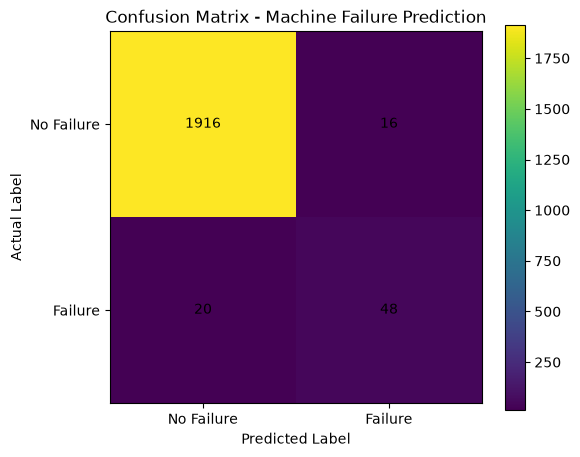

In [14]:
# Visualize the confusion matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix - Machine Failure Prediction")

plt.colorbar()

plt.xticks(
    [0, 1],
    ["No Failure", "Failure"]
)

plt.yticks(
    [0, 1],
    ["No Failure", "Failure"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# Add values inside the matrix
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [15]:
# Get feature importance from the trained Random Forest model

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

# Sort from highest to lowest importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
3,Torque [Nm],0.322362
2,Rotational speed [rpm],0.286201
4,Tool wear [min],0.213284
0,Air temperature [K],0.098706
1,Process temperature [K],0.063921
5,Type_L,0.009123
6,Type_M,0.006403


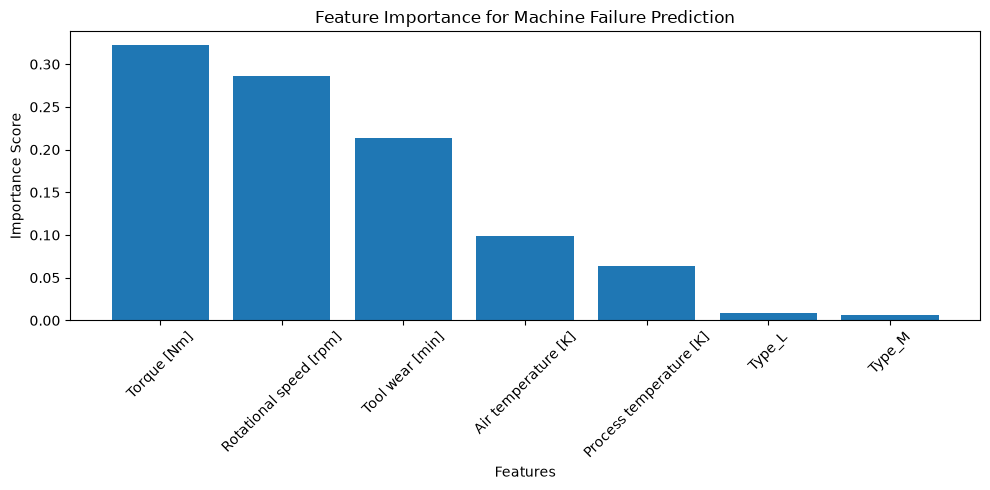

In [16]:
plt.figure(figsize=(10, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xticks(rotation=45)

plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.title("Feature Importance for Machine Failure Prediction")

plt.tight_layout()

plt.show()

In [17]:
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the trained model
joblib.dump(
    model,
    "../models/maintenance_failure_model.pkl"
)

print("Maintenance prediction model saved successfully!")

Maintenance prediction model saved successfully!
